# Análisis de movilidad urbana y productividad económica

Este análisis evalúa la relación entre la movilidad urbana y la productividad económica en distintas ciudades. A partir de datos de TomTom Traffic Index y OECD Cities, se integran indicadores de congestión, tiempos de viaje y desempeño económico para identificar patrones relevantes para la inversión en infraestructura de transporte.

## Carga y exploración de datos

### Carga de datos y vista rápida

Se cargan los datasets de movilidad y economía urbana y se realiza una inspección inicial de su estructura y contenido.

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [4]:
# Inspeccionar primeras filas del dataset de tráfico
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
# Inspeccionar primeras filas del dataset de economía
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


---
## Limpieza y preparación de datos

### Explorar la estructura y tipos de datos

Se revisan la estructura, los tipos de datos y la presencia de valores nulos en ambos datasets.

In [6]:
# Estructura y diagnóstico de nulos de traffic
print("Estructura de traffic:")
print(traffic.info())
print("\nCantidad de nulos por columna:\n", traffic.isna().sum())

Estructura de traffic:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 

En la estructura del DataFrame traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object. Necesitan conversión a `datetime`.
- No hay valores nulos 

In [7]:
# Estructura y diagnóstico de nulos de eco
print("Estructura de eco:")
print(eco.info())
print("\nCantidad de nulos por columna:\n",eco.isna().sum())

Estructura de eco:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
None

Cantidad de nulos por columna:
 Year               0
City               0
Country            0
City GDP/capita    0
Unemployment %     0
PM2.5 (μg/m³)      0
Population (M)     0
dtype: int64


En la estructura del DataFrame eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` son de tipo object. Necesitan conversión a FLOAT.
- No hay valores nulos 

### Limpieza y preparación de datos

Los nombres de las columnas se normalizan en formato `snake_case` para mejorar la consistencia y facilitar las transformaciones posteriores.

In [8]:
# Estandarizar los nombres de las columnas de traffic 
traffic.columns = ['country', 
                   'city', 
                   'update_time_utc', 
                   'jams_delay', 
                   'traffic_index_live',
                   'jams_length_kms', 
                   'jams_count', 
                   'traffic_index_week_ago', 
                   'update_time_utc_week_ago', 
                   'travel_time_live_per_10kms_mins', 
                   'travel_time_hist_per_10kms_mins', 
                   'mins_delay'
]

# Verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [9]:
# Estandarizar los nombres de las columnas de eco
eco.columns = ['year', 
               'city', 
               'country', 
               'city_gdp_capita', 
               'unemployment_pct',
               'pm25', 
               'population_m'
]

# Verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### Corregir formatos numéricos y de fecha

Las columnas temporales se convierten a formato `datetime` y las variables económicas se normalizan para permitir su conversión a tipos numéricos. También se calcula la población en unidades absolutas a partir de la variable expresada en millones.

In [10]:
# DataFrame traffic - Convertir update_time_utc y update_time_utc_week_ago a fecha
traffic["update_time_utc"] = pd.to_datetime(traffic["update_time_utc"], errors="coerce", utc=True)
traffic["update_time_utc_week_ago"] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce", utc=True)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   traffic_index_week_ago           1004464 non-null  float64            
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [11]:
# DataFrame eco - Limpiar separadores y convertir columnas numéricas
eco["city_gdp_capita"] = eco["city_gdp_capita"].astype(str).str.replace(".", "").str.replace(",", ".").astype(float)
eco["unemployment_pct"] = eco["unemployment_pct"].astype(str).str.replace("%", "").astype(float)
eco["pm25"] = eco["pm25"].astype(str).str.replace(",", ".").astype(float)
eco["population_m"] = eco["population_m"].astype(str).str.replace(",", ".").astype(float)

# Creación de nueva columna con la población total en unidades absolutas (Multiplica * 1000000)
eco["population"] = eco["population_m"] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


---
## Filtrado temporal

### Selección de registros de 2024

Se extrae el año de las mediciones de tráfico y se filtran ambos datasets para conservar únicamente los registros correspondientes a 2024. Los subconjuntos se almacenan como copias independientes para preservar los DataFrames originales.

In [12]:
# DataFrame traffic - Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [13]:
# Filtrar los registros del año 2024
traffic_2024 = traffic[traffic["year"] == 2024].copy() 
eco_2024 = eco[eco["year"] == 2024].copy()

# Revisar DataFrames nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


---
## Agregación de indicadores de movilidad

### Promedios anuales de tráfico por ciudad

Debido a que el dataset de tráfico contiene múltiples mediciones por ciudad, los indicadores de movilidad se agregan mediante su promedio anual a nivel de ciudad y país. Esta transformación permite obtener una única observación por ciudad para 2024 y facilita su posterior integración con los indicadores económicos.

In [14]:
# Calcular los promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(["city", "country", "year"])\
                            .agg({
                                 "jams_delay": "mean",
                                 "traffic_index_live": "mean",
                                 "jams_length_kms": "mean",
                                 "jams_count": "mean",
                                 "mins_delay": "mean",
                                 "travel_time_live_per_10kms_mins": "mean",
                                 "travel_time_hist_per_10kms_mins": "mean"
                            }).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Ciudades con mayor retraso promedio

In [15]:
# Revisar cual ciudad tiene el mayor tiempo promedio de tráfico
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


Entre las ciudades con mayores niveles promedio de retraso por congestión destacan capitales como Ciudad de México, Tokio, Londres y Manila. La presencia de grandes áreas metropolitanas entre los valores más elevados sugiere la conveniencia de analizar factores como población, extensión urbana e infraestructura de transporte.

---
## Integración de datos de movilidad y economía

### Integración de los datasets

Los indicadores agregados de movilidad se integran con las variables económicas mediante una unión interna (`INNER JOIN`) utilizando city y year como claves comunes.

In [16]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']
right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets con las claves de unión "city" y "year"
merged = pd.merge(traffic_2024_small, eco_2024_small, on=["city", "year"], how="inner")

# Mostrar el encabezado del nuevo DataFrame
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


La unión se realiza por ciudad y año debido a las diferencias de codificación del país entre ambas fuentes. Las coincidencias resultantes se validan posteriormente para comprobar la consistencia de los registros integrados.

---
## Análisis exploratorio y visualización

### Análisis de movilidad y productividad económica

Se analiza la distribución del retraso por congestión y del PIB per cápita, así como su comportamiento conjunto por ciudad, con el objetivo de identificar valores atípicos y posibles patrones entre movilidad y productividad económica.

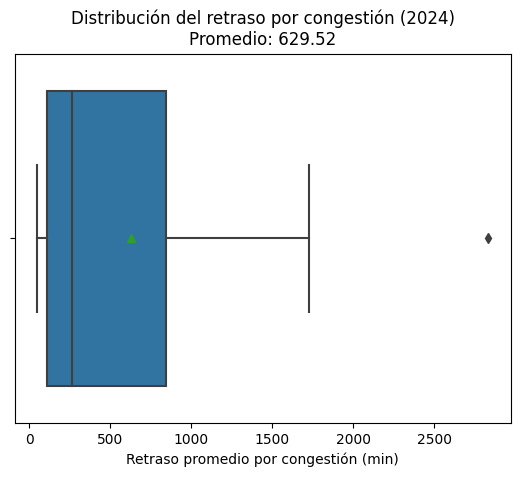

In [17]:
# Crear boxplot para observar el comportamiento de los minutos de congestion jams_delay
# Usamos "showmeans=True" para que el gráfico muestre el promedio de jams_delay
sns.boxplot(data=merged, x="jams_delay", showmeans=True)

# Obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()

# Agregar título que incluya el valor promedio
plt.title(f'Distribución del retraso por congestión (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel("Retraso promedio por congestión (min)")
plt.show()

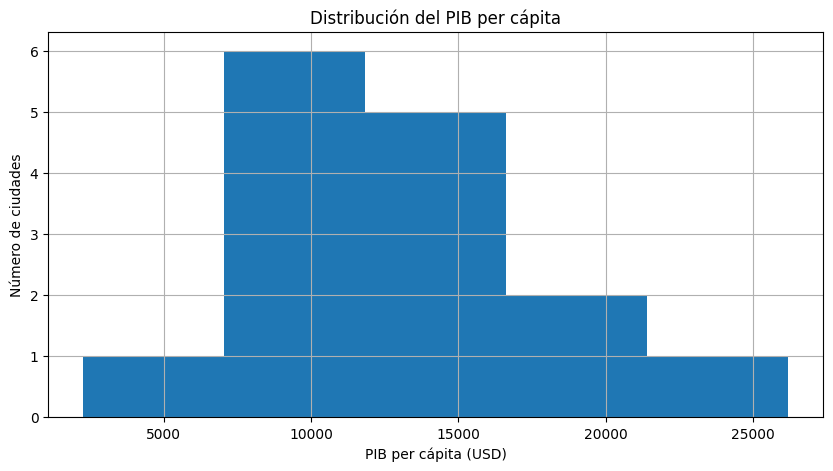

In [18]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp_capita"].hist(bins=5, figsize=(10,5))
plt.title("Distribución del PIB per cápita")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Número de ciudades")
plt.show()

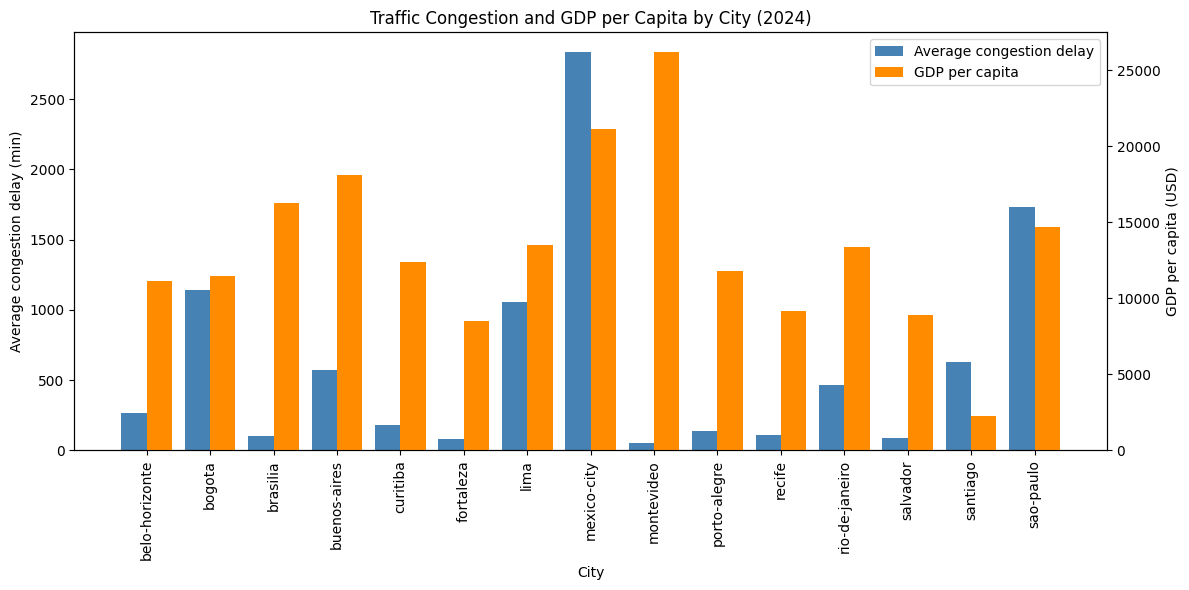

In [19]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
x = np.arange(len(merged["city"]))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje primario: retraso por congestión
bars_delay = ax1.bar(
    x - width / 2,
    merged["jams_delay"],
    width=width,
    color="steelblue",
    label="Average congestion delay"
)

ax1.set_xlabel("City")
ax1.set_ylabel("Average congestion delay (min)")

# Eje secundario: PIB per cápita
ax2 = ax1.twinx()

bars_gdp = ax2.bar(
    x + width / 2,
    merged["city_gdp_capita"],
    width=width,
    color="darkorange",
    label="GDP per capita"
)

ax2.set_ylabel("GDP per capita (USD)")

# Etiquetas del eje X
ax1.set_xticks(x)
ax1.set_xticklabels(merged["city"], rotation=90)

# Leyenda conjunta
ax1.legend(
    [bars_delay, bars_gdp],
    ["Average congestion delay", "GDP per capita"],
    loc="upper right"
)

plt.title("Traffic Congestion and GDP per Capita by City (2024)")
plt.tight_layout()
plt.savefig("congestion_gdp_comparison.png", dpi=300, bbox_inches="tight") # Guardar la imagen
plt.show()

### Interpretación de resultados

A partir de las visualizaciones, no se aprecia una relación proporcional clara entre el PIB per cápita y el retraso promedio por congestión. Las ciudades con mayor PIB per cápita presentan niveles variados de congestión, mientras que ciudades con menor productividad económica muestran comportamientos igualmente diversos. Visualmente, no se identifica una relación lineal evidente entre ambas variables.

---
## Exportación de resultados

### Dataset procesado

El dataset consolidado se exporta en formato CSV para facilitar su reutilización en análisis posteriores.

In [20]:
# Exportar el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

---
## Resumen ejecutivo

### Contexto y objetivo

Se analizó la relación entre indicadores de movilidad urbana (congestión, retrasos y tiempos de viaje) y productividad económica (PIB per cápita, desempleo, contaminación y población). El objetivo fue identificar posibles patrones que permitan apoyar la toma de decisiones sobre inversiones en infraestructura de transporte para aumentar productividad y bienestar de la población.

### Cobertura de datos

El análisis se centra en datos del año 2024, y comprende un conjunto de 15 ciudades distribuidas en 7 países: Argentina, Brasil, Chile, Colombia, México, Perú, Uruguay.

### Metodología

Se realizaron: 
* Limpieza y estandarización de datos mediante la normalización de nombres de columnas y la conversión de formatos numéricos y temporales.
* Agregación de datos para obtener los promedios, por ciudad y año, de los indicadores de movilidad urbana. Posteriormente, se unieron los datos de tráfico y economía urbana utilizando una INNER JOIN, utilizando ciudad y año como clave conjunta.
* Visualizaciones descriptivas: **Boxplot** para observar la distribución y valores atípicos de los minutos promedio de retraso, por ciudad y año. **Histograma** para conocer la forma y distribución del PIB per capita. **Gráfico de barras combinado con doble eje** para conocer la relación entre ambas métricas.

### Hallazgos principales

No se observó una relación visual clara entre un mayor PIB per cápita y mayores niveles de congestión. Existen ciudades con economías fuertes y baja congestión, como Montevideo, mientras que otras, como Ciudad de México, presentan altos niveles tanto de productividad económica como de congestión. Además, Ciudad de México destaca como un valor atípico en la variable de retraso promedio (jams_delay), por lo que representa un caso de interés para un análisis más detallado.

Con la información disponible no es posible concluir que la productividad económica explique directamente el comportamiento del tráfico urbano.

### Recomendaciones

De igual forma, ciudades como **Bogotá** y **Lima** presentan una combinación de alta congestión con un PIB per cápita inferior al de otras ciudades de la muestra analizada. Los datos sugieren que estas ciudades podrían considerarse candidatas para un análisis más detallado, previo a la toma de decisiones sobre inversión en infraestructura de transporte.

No obstante, se recomienda complementar este análisis con medidas de correlación y ampliar la cobertura temporal para validar los resultados.